# **Linear regression**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
TrainingDataFrame["Time_flow"] = np.arange(1, len(TrainingDataFrame)+1)
historic_columns.append("Time_flow")

# **Linear regression**

a.k.a. plain and simple :)

In [4]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        


        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

In [5]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [6]:
np.mean(list(mean_performances.values()))
#1.8022770841893423

np.float64(1.8017841056052721)

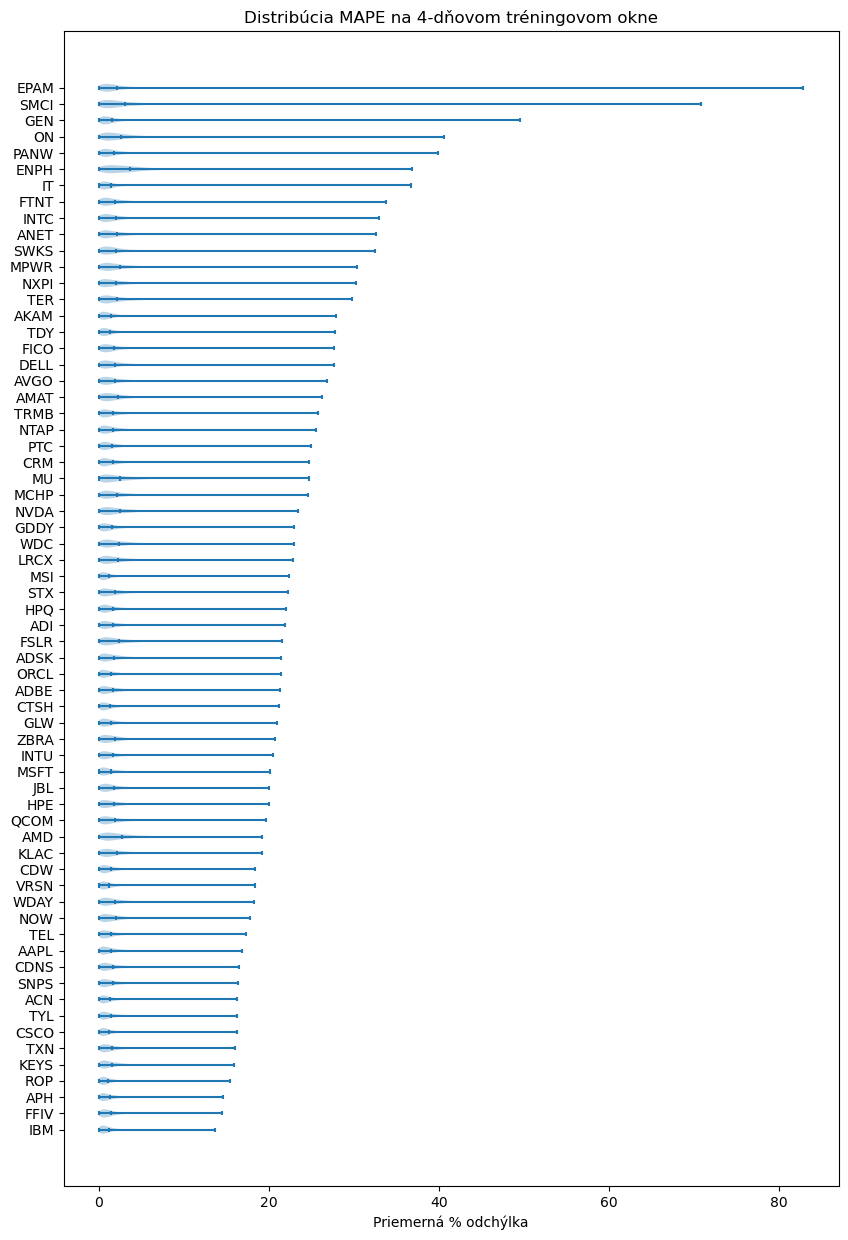

In [7]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [8]:
mean_performances

{'ROP': np.float64(1.1092164946739018),
 'IBM': np.float64(1.1700418831447863),
 'CSCO': np.float64(1.2065129419200613),
 'MSI': np.float64(1.2091976955107482),
 'VRSN': np.float64(1.2282125023222494),
 'ACN': np.float64(1.2603521681576346),
 'CTSH': np.float64(1.3030517164745332),
 'APH': np.float64(1.307024271109598),
 'TDY': np.float64(1.312076967323749),
 'MSFT': np.float64(1.3624027173223625),
 'AKAM': np.float64(1.3636527787615698),
 'TEL': np.float64(1.3890656576603022),
 'TYL': np.float64(1.390870494683288),
 'ORCL': np.float64(1.399357523364584),
 'FFIV': np.float64(1.4046678042315088),
 'IT': np.float64(1.4137841836381628),
 'CDW': np.float64(1.4438819012995576),
 'GLW': np.float64(1.467321549991714),
 'AAPL': np.float64(1.474584694232615),
 'GEN': np.float64(1.4869624739154563),
 'KEYS': np.float64(1.5485055832570345),
 'TXN': np.float64(1.5648907069820075),
 'GDDY': np.float64(1.5654956724327997),
 'PTC': np.float64(1.589712413960652),
 'INTU': np.float64(1.6275334293184556

In [9]:
np.mean([np.mean(i) for i in performance_simple.values()])
#0.4414159701090096

np.float64(0.4416316782866607)

# **Date-wise model dominance over naive**

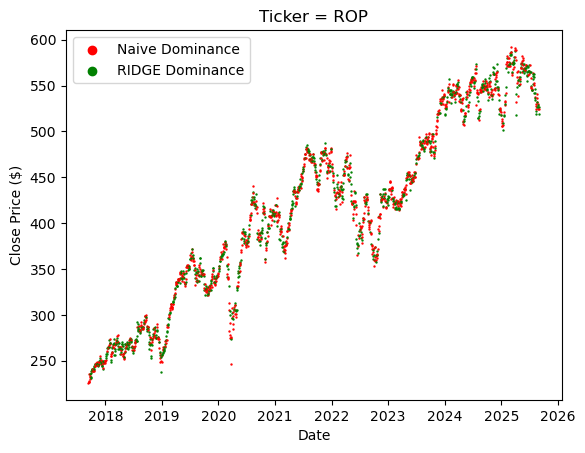

In [10]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

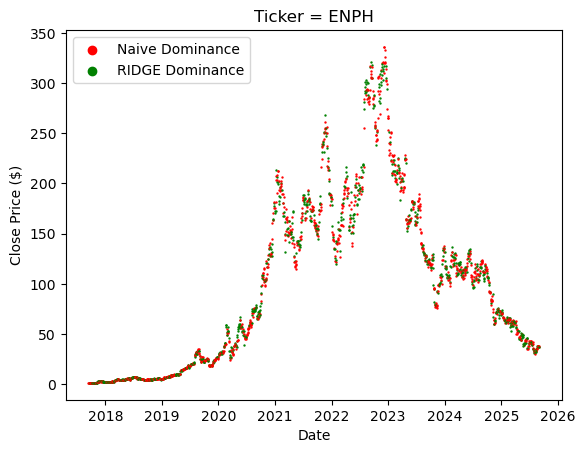

In [11]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

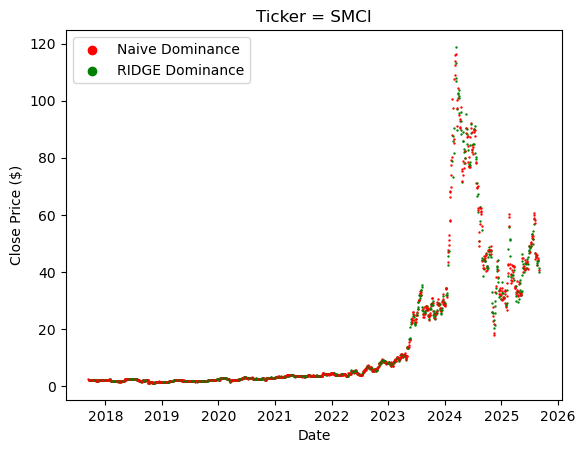

In [12]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

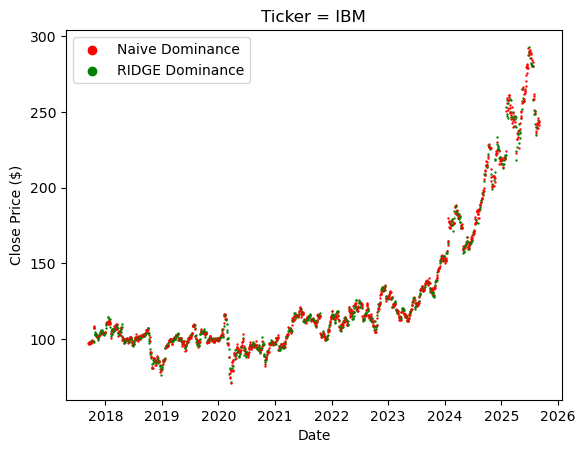

In [13]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

# **Analysis of dominance in detail**

In [11]:
# COVID
# We perform analysis of precision between February and March 2020 -> Covid recession

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2020-02-01") & (TrainingDataFrame["Date"] <= "2020-03-31")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

covid_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    covid_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(covid_dominances.values())))

40.825515947467174


In [12]:
sorted(covid_dominances.items(), key=lambda x: x[1], reverse=True)

[('JBL', 53.65853658536585),
 ('ENPH', 51.21951219512195),
 ('APH', 48.78048780487805),
 ('DELL', 48.78048780487805),
 ('IT', 48.78048780487805),
 ('IBM', 48.78048780487805),
 ('NXPI', 48.78048780487805),
 ('SWKS', 48.78048780487805),
 ('SMCI', 48.78048780487805),
 ('AVGO', 46.34146341463415),
 ('HPQ', 46.34146341463415),
 ('NTAP', 46.34146341463415),
 ('PANW', 46.34146341463415),
 ('PTC', 46.34146341463415),
 ('CRM', 46.34146341463415),
 ('VRSN', 46.34146341463415),
 ('WDC', 46.34146341463415),
 ('FFIV', 43.90243902439025),
 ('FICO', 43.90243902439025),
 ('GDDY', 43.90243902439025),
 ('HPE', 43.90243902439025),
 ('MU', 43.90243902439025),
 ('MSFT', 43.90243902439025),
 ('ORCL', 43.90243902439025),
 ('TEL', 43.90243902439025),
 ('TDY', 43.90243902439025),
 ('TRMB', 43.90243902439025),
 ('TYL', 43.90243902439025),
 ('WDAY', 43.90243902439025),
 ('AKAM', 41.46341463414634),
 ('CTSH', 41.46341463414634),
 ('FSLR', 41.46341463414634),
 ('MCHP', 41.46341463414634),
 ('MSI', 41.4634146341463

In [13]:
# Trumpove mecheche
# We perform analysis of precision between of April 2025 -> Trump's tarrifs

# Number of trading days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2025-04-01") & (TrainingDataFrame["Date"] <= "2025-04-30")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

trump_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    trump_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(trump_dominances.values())))

45.49450549450549


In [14]:
sorted(trump_dominances.items(), key=lambda x: x[1], reverse=True)

[('AKAM', 66.66666666666667),
 ('ADSK', 61.904761904761905),
 ('IBM', 61.904761904761905),
 ('TDY', 61.904761904761905),
 ('AAPL', 57.142857142857146),
 ('ANET', 57.142857142857146),
 ('CTSH', 57.142857142857146),
 ('GEN', 57.142857142857146),
 ('GDDY', 57.142857142857146),
 ('INTU', 57.142857142857146),
 ('ORCL', 57.142857142857146),
 ('SNPS', 57.142857142857146),
 ('CDNS', 52.38095238095238),
 ('CDW', 52.38095238095238),
 ('CSCO', 52.38095238095238),
 ('FFIV', 52.38095238095238),
 ('FICO', 52.38095238095238),
 ('FTNT', 52.38095238095238),
 ('KLAC', 52.38095238095238),
 ('PANW', 52.38095238095238),
 ('QCOM', 52.38095238095238),
 ('ACN', 47.61904761904762),
 ('ADBE', 47.61904761904762),
 ('AMAT', 47.61904761904762),
 ('AVGO', 47.61904761904762),
 ('LRCX', 47.61904761904762),
 ('MSFT', 47.61904761904762),
 ('MPWR', 47.61904761904762),
 ('MSI', 47.61904761904762),
 ('PTC', 47.61904761904762),
 ('NOW', 47.61904761904762),
 ('WDC', 47.61904761904762),
 ('APH', 42.857142857142854),
 ('GLW',

**Year-wise dominance**

In [15]:
years = [str(i) for i in range(2017, 2026)]
dominances = []

for year in years:
    trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= f"{year}-01-01") & (TrainingDataFrame["Date"] <= f"{year}-12-31")]["Date"].values
    trading_days = [str(i).split("T")[0] for i in trading_days]

    year_dominances = {}

    for ticker in tickers["Ticker"]:
        counter = 0
        for day in model_dominance[ticker]:
            if day in trading_days:
                counter += 1
        year_dominances[ticker] = counter*100 / len(trading_days)

    dominances.append(np.mean(list(year_dominances.values())))
    print(year, np.mean(list(year_dominances.values())))

2017 42.3076923076923
2018 46.25804474410052
2019 45.31746031746032
2020 43.78838552751597
2021 44.328449328449324
2022 44.24762488507508
2023 40.33846153846153
2024 44.737484737484735
2025 43.82312298479963


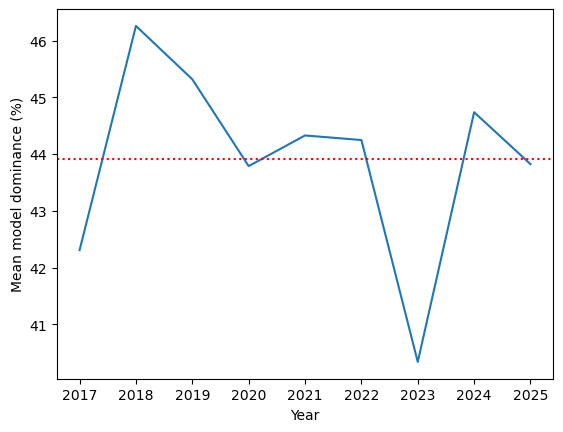

In [16]:
plt.plot(years, dominances)

plt.xlabel("Year")
plt.ylabel("Mean model dominance (%)")

plt.axhline(np.mean(dominances), linestyle="dotted", color="red")

plt.show()